# Latent variable models

This notebook is a lean syntax tour of mixle's latent-variable models: how to construct each distribution and how to fit it with an estimator. Every model shares the same pattern as the plain distributions in `distributions_and_combinators` -- a `*Distribution` paired with a `*Estimator` -- but here an unobserved (latent) state couples the variables together.

Models covered:

* Mixture model (the basic latent-variable pattern)
* Composite mixture (mixed-type components)
* Hierarchical and joint mixtures
* Hidden Markov Model
* Latent Dirichlet Allocation

The data are tiny and synthetic; the focus is the API, not the fit quality. Choosing the number of components, restarts, and convergence criteria is left to the data-science notebook linked at the end.


In [1]:
import numpy as np
import io
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


%matplotlib inline
from mixle.inference.estimation import optimize
rng = np.random.RandomState(0)

In [2]:
from mixle.stats import BernoulliEstimator, BernoulliSetDistribution, BernoulliSetEstimator, CategoricalDistribution, CategoricalEstimator, ChowLiuTreeEstimator, CompositeDistribution, CompositeEstimator, DiracLengthMixtureDistribution, DiracLengthMixtureEstimator, DirichletProcessMixtureEstimator, ErdosRenyiGraphDistribution, ErdosRenyiGraphEstimator, GammaDistribution, GaussianDistribution, GaussianEstimator, GeometricDistribution, GeometricEstimator, HeterogeneousMixtureDistribution, HeterogeneousMixtureEstimator, HeterogeneousPCFGDistribution, HiddenMarkovEstimator, HiddenMarkovModelDistribution, HierarchicalDirichletProcessMixtureEstimator, HierarchicalMixtureDistribution, HierarchicalMixtureEstimator, IntegerChowLiuTreeEstimator, IndianBuffetProcessDistribution, IndianBuffetProcessEstimator, IntegerCategoricalDistribution, IntegerCategoricalEstimator, JointMixtureDistribution, JointMixtureEstimator, LDADistribution, LDAEstimator, MarkovChainDistribution, MarkovChainEstimator, MixtureDistribution, MixtureEstimator, MultivariateGaussianDistribution, MultivariateGaussianEstimator, NormalGammaDistribution, OptionalDistribution, OptionalEstimator, PoissonDistribution, PoissonEstimator, SegmentalHiddenMarkovModelDistribution, SegmentalHiddenMarkovModelEstimator, SemiSupervisedMixtureDistribution, SequenceDistribution, SequenceEstimator, SparseMarkovAssociationEstimator, StochasticBlockGraphDistribution, StochasticBlockGraphEstimator, StudentTDistribution, TreeHiddenMarkovEstimator, TreeHiddenMarkovModelDistribution, seq_encode
from mixle.inference import seq_estimate
from mixle.inference.estimation import optimize

## Mixture models
A `MixtureDistribution` takes a list of `components` and a weight vector `w` giving the probability of each component. The matching `MixtureEstimator` takes one estimator per component. This is the basic latent-variable pattern: the component index is the hidden state, marginalized out when scoring an observation.


In [3]:
# Sample from a known three-component Gaussian mixture
d1 = MultivariateGaussianDistribution([-8.0, -8.0], [[2.0, 1.0], [1.0, 2.0]])
d2 = MultivariateGaussianDistribution([ 0.0,  0.0], [[2.0, -1.0], [-1.0, 2.0]])
d3 = MultivariateGaussianDistribution([ 5.0,  1.0], [[2.0, 1.0], [1.0, 2.0]])

dist = MixtureDistribution([d1, d2, d3], [0.4, 0.4, 0.2])
data = dist.sampler(seed=1).sample(size=1000)

In [4]:
# Fit: one estimator per component, then optimize (runs EM to convergence)
est = MixtureEstimator([MultivariateGaussianEstimator()] * 3)
model = optimize(data, est, max_its=200, print_iter=50)

Component parameters live on `model.components` and the mixing weights on `model.w`. The posterior over the hidden component for a single observation comes from `posterior`, and `seq_posterior` does the same for an encoded batch.


In [5]:
print('weights:', model.w)
for c in model.components:
    print(c)

weights: [0.38100004 0.20197376 0.41702619]
MultivariateGaussianDistribution([np.float64(-7.958376297190244), np.float64(-8.045217321769488)], [[np.float64(1.9078929520909753), np.float64(0.8771120692441006)], [np.float64(0.8771120692441006), np.float64(1.9008414494668442)]], name=None, keys=None)
MultivariateGaussianDistribution([np.float64(5.050790644815665), np.float64(1.0433642804329617)], [[np.float64(1.7999504817972225), np.float64(0.910972178565286)], [np.float64(0.910972178565286), np.float64(1.7681961565880115)]], name=None, keys=None)
MultivariateGaussianDistribution([np.float64(0.10151871832842395), np.float64(-0.041608246113184116)], [[np.float64(2.031711283849316), np.float64(-0.9949090175826824)], [np.float64(-0.9949090175826824), np.float64(1.9275505626538314)]], name=None, keys=None)


posterior(data[0]): [1.00000000e+00 3.10306925e-21 3.06352642e-26]


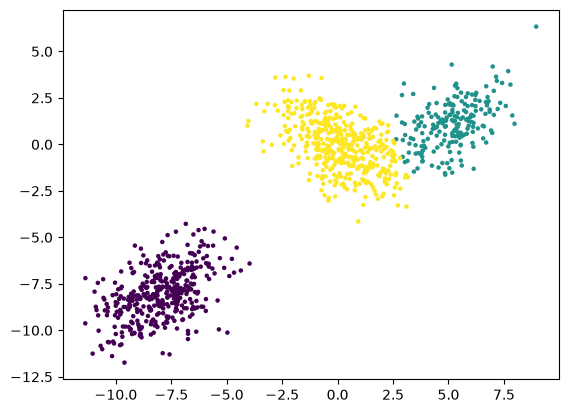

In [6]:
# Per-observation posterior P(component | observation)
print('posterior(data[0]):', model.posterior(data[0]))

# Vectorized over an encoded batch -> (n, n_components) array
enc = model.dist_to_encoder().seq_encode(data)
post = model.seq_posterior(enc)
colors = post.argmax(axis=1)

plt.scatter([u[0] for u in data], [u[1] for u in data], c=colors, s=5);

### Composite mixture (mixed-type components)
Each component can be a `CompositeDistribution`, so a single mixture can model a heterogeneous, conditionally-independent feature tuple. Here each observation is `(real number, maybe-missing geometric, string sequence, set of tags)`. Construction and fitting are unchanged -- the components are just richer.


In [7]:
def make_component(g_mu, opt_p, opt_geom, mc_init, mc_trans, set_p):
    return CompositeDistribution([
        GaussianDistribution(g_mu, 1.0),
        OptionalDistribution(GeometricDistribution(opt_geom), p=opt_p),
        MarkovChainDistribution(mc_init, mc_trans, len_dist=PoissonDistribution(8.0)),
        BernoulliSetDistribution(set_p),
    ])

c1 = make_component(-10.0, 0.1,  0.1, {'a':0.5,'b':0.5}, {'a':{'a':0.2,'b':0.8},'b':{'a':0.8,'b':0.2}}, {'a':0.1,'b':0.3,'c':0.7,'d':0.9})
c2 = make_component( 10.0, 0.2,  0.2, {'a':0.5,'b':0.5}, {'a':{'a':0.8,'b':0.2},'b':{'a':0.2,'b':0.8}}, {'a':0.9,'b':0.8,'c':0.1,'d':0.1})
c3 = make_component(  0.0, 0.01, 0.9, {'a':0.8,'b':0.2}, {'a':{'a':0.5,'b':0.5},'b':{'a':0.2,'b':0.8}}, {'a':0.5,'b':0.5,'c':0.5,'d':0.8})

dist = MixtureDistribution([c1, c2, c3], [0.4, 0.3, 0.3])
data = dist.sampler(seed=1).sample(size=800)
print('a sample:', data[0])

a sample: (np.float64(-10.283237338226957), np.int64(2), ['a', 'b', 'a', 'b', 'b', 'a'], ['c', 'd'])


In [8]:
# A CompositeEstimator mirrors the component structure; pseudo_count smooths the fit
comp_est = CompositeEstimator((
    GaussianEstimator(),
    OptionalEstimator(GeometricEstimator(), est_prob=True),
    MarkovChainEstimator(len_estimator=PoissonEstimator()),
    BernoulliSetEstimator(),
))
est = MixtureEstimator([comp_est] * 3, pseudo_count=1.0)
model = optimize(data, est, max_its=200, rng=np.random.RandomState(1), print_iter=50)

# The Gaussian field of each fitted component
for c in model.components:
    print(c.dists[0])

GaussianDistribution(10.019666124683914, 1.097841625879534, name=None, keys=None)
GaussianDistribution(-10.050321962088494, 0.9798634273640304, name=None, keys=None)
GaussianDistribution(0.10670516616944661, 1.1094010496874382, name=None, keys=None)


#### Imputing a missing field

When a field is missing (the optional geometric here is `None` for some samples), `posterior` still returns the component distribution. Mixing the per-component conditionals by that posterior gives the predictive distribution for the missing value -- and its mean analytically.


In [9]:
point = next(u for u in data if u[1] is None)
posterior = model.posterior(point)

# P(missing field) = sum_i P(component=i | observed) * P(field | component=i)
missing = MixtureDistribution([c.dists[1].dist for c in model.components], posterior)
est_mean = np.dot(missing.w, [1.0 / c.p for c in missing.components])
print('posterior over components:', posterior)
print('expected value of the missing geometric field:', est_mean)

posterior over components: [1.00000000e+00 3.44325992e-82 1.53874510e-16]
expected value of the missing geometric field: 5.2326732658491055


## Hierarchical mixture model
A hierarchical mixture is a mixture of mixtures that share a common set of `topics`. `HierarchicalMixtureDistribution` takes the shared topics, outer weights `w`, an inner-weight matrix `taus` (one row per outer cluster), and a `len_dist` for the sequence length. `HierarchicalMixtureEstimator` just needs the topic estimators and the number of outer mixtures.


In [10]:
topics = [GaussianDistribution(-5.0, 1.0), GaussianDistribution(0.0, 1.0), GaussianDistribution(5.0, 1.0)]
taus = [[0.34, 0.33, 0.33], [0.8, 0.1, 0.1], [0.1, 0.8, 0.1], [0.1, 0.1, 0.8]]
w = [0.4, 0.2, 0.2, 0.2]

dist = HierarchicalMixtureDistribution(topics, w, taus, len_dist=CategoricalDistribution({5: 1.0}))
data = dist.sampler(seed=1).sample(800)

In [11]:
est = HierarchicalMixtureEstimator([GaussianEstimator()] * 3, 4)
model = optimize(data, est, 200, rng=np.random.RandomState(1), print_iter=50)

print('topics:', *model.topics, sep='\n')
print('outer weights w:', model.w)
print('inner weights taus:', model.taus, sep='\n')

topics:
GaussianDistribution(-5.031540540351798, 0.9327299541714451, name=None, keys=None)
GaussianDistribution(0.018518796560657354, 1.0955996211009469, name=None, keys=None)
GaussianDistribution(4.9855624274322965, 0.9715178424995735, name=None, keys=None)
outer weights w: [0.22715551 0.40974641 0.19199867 0.1710994 ]
inner weights taus:
[[0.80089768 0.11074179 0.08836053]
 [0.31204664 0.31019979 0.37775358]
 [0.09368899 0.81915448 0.08715653]
 [0.07368198 0.10266043 0.8236576 ]]


## Joint mixture model
A `JointMixtureDistribution` links the hidden states of two mixtures through one joint latent-state table, `joint_weights[i][j] = P(state1 = i, state2 = j)`; the marginal weights `w1`/`w2` and the conditional tables `taus12`/`taus21` are all derived from it (the constructor still accepts the four-argument form, but `w2` and `taus21` are then redundant with `w1` and `taus12` and are ignored with a deprecation warning). It is fit on fully observed pairs `(x, y)`, but the linked states let you predict one block's posterior from the other. `JointMixtureEstimator` takes the two lists of component estimators.


In [12]:
d11 = CompositeDistribution([CategoricalDistribution({'a':1.0,'b':0.0,'c':0.0}), GaussianDistribution(-2.0, 1.0)])
d12 = CompositeDistribution([CategoricalDistribution({'a':0.0,'b':1.0,'c':0.0}), GaussianDistribution( 0.0, 1.0)])
d13 = CompositeDistribution([CategoricalDistribution({'a':0.0,'b':0.0,'c':1.0}), GaussianDistribution( 2.0, 1.0)])

d21 = SequenceDistribution(GaussianDistribution( 2.0, 1.0), PoissonDistribution(3.0))
d22 = SequenceDistribution(GaussianDistribution( 0.0, 1.0), PoissonDistribution(3.0))
d23 = SequenceDistribution(GaussianDistribution(-2.0, 1.0), PoissonDistribution(3.0))

w1 = [0.6, 0.3, 0.1]
taus12 = [[0.8, 0.1, 0.1], [0.1, 0.8, 0.1], [0.1, 0.1, 0.8]]
# the joint law: P(state1 = i, state2 = j) = w1[i] * taus12[i][j]
joint_weights = [[w * t for t in row] for w, row in zip(w1, taus12)]

dist = JointMixtureDistribution([d11, d12, d13], [d21, d22, d23], joint_weights=joint_weights)
data = dist.sampler(seed=1).sample(2000)

In [13]:
est1 = CompositeEstimator([CategoricalEstimator(pseudo_count=1.0), GaussianEstimator()])
est2 = SequenceEstimator(GaussianEstimator(), PoissonEstimator())
est = JointMixtureEstimator([est1] * 3, [est2] * 3, pseudo_count=(0.001, 0.001, 0.001))
model = optimize(data, est, max_its=200, rng=np.random.RandomState(1), print_iter=50)

print('block-1 components:', *model.components1, sep='\n')
print('\ncross-block transition taus12:', model.taus12, sep='\n')

block-1 components:
CompositeDistribution((CategoricalDistribution({'a': np.float64(0.001768015724377219), 'b': np.float64(0.010447783583482258), 'c': np.float64(0.9877842006921406)}, default_value=0.0, name=None, keys=None),GaussianDistribution(2.0408199351420575, 0.842705835402373, name=None, keys=None)))
CompositeDistribution((CategoricalDistribution({'a': np.float64(0.005777169011075379), 'b': np.float64(0.9876630073146283), 'c': np.float64(0.0065598236742963004)}, default_value=0.0, name=None, keys=None),GaussianDistribution(-0.025472710482620134, 1.0551353606847929, name=None, keys=None)))
CompositeDistribution((CategoricalDistribution({'a': np.float64(0.998786677328491), 'b': np.float64(0.0009119741932084493), 'c': np.float64(0.00030134847830042775)}, default_value=0.0, name=None, keys=None),GaussianDistribution(-2.022629291283572, 0.9899007999226205, name=None, keys=None)))

cross-block transition taus12:
[[0.74635632 0.13512933 0.11851435]
 [0.07789306 0.07841745 0.84368948]
 

## Hidden Markov model
`HiddenMarkovModelDistribution` models a sequence whose hidden states follow a Markov chain. It takes the emission distributions, the initial-state weights, the transition matrix, an unused positional argument (`None`), and a `len_dist`. Emissions can be any mixle distribution -- here a composite of a Gaussian and a categorical. `HiddenMarkovEstimator` takes one emission estimator per state.


In [14]:
e1 = CompositeDistribution((GaussianDistribution(-5.0, 1.0), CategoricalDistribution({'a':0.4,'b':0.4,'c':0.1,'d':0.1})))
e2 = CompositeDistribution((GaussianDistribution( 0.0, 1.0), CategoricalDistribution({'a':0.1,'b':0.1,'c':0.4,'d':0.4})))
e3 = CompositeDistribution((GaussianDistribution( 5.0, 1.0), CategoricalDistribution({'a':0.1,'b':0.4,'c':0.4,'d':0.1})))

trans = [[0.8, 0.1, 0.1], [0.1, 0.8, 0.1], [0.1, 0.1, 0.8]]
dist = HiddenMarkovModelDistribution([e1, e2, e3], [0.4, 0.4, 0.2], trans, None, len_dist=PoissonDistribution(8.0))
data = dist.sampler(seed=1).sample(500)
print('a sequence:', data[0])

a sequence: [(np.float64(-0.2832373382269573), 'd'), (np.float64(-1.805910229021931), 'c'), (np.float64(0.5520105058044739), 'd'), (np.float64(-4.074451527902555), 'a'), (np.float64(-6.931790730551266), 'a'), (np.float64(-4.859725443148636), 'a'), (np.float64(-4.310524946311117), 'a')]


In [15]:
emit_est = CompositeEstimator((GaussianEstimator(), CategoricalEstimator(pseudo_count=1.0)))
est = HiddenMarkovEstimator([emit_est] * 3, pseudo_count=(1.0, 1.0))
model = optimize(data, est, max_its=100, rng=np.random.RandomState(1), print_iter=25)

# The Gaussian part of each fitted emission
for state in model.topics:
    print(state.dists[0])

GaussianDistribution(-0.0019264026779259075, 1.0026668540452264, name=None, keys=None)
GaussianDistribution(-5.00964713406578, 1.017755204258817, name=None, keys=None)
GaussianDistribution(5.0641600229789745, 0.9886466976696173, name=None, keys=None)


## Latent Dirichlet allocation (LDA)
`LDADistribution` takes a list of `topics`, a Dirichlet parameter `alpha`, and a `len_dist` for document length. Each document draws a topic mixture from the Dirichlet, then draws tokens from the chosen topics. `LDAEstimator` takes one estimator per topic. Documents are passed as lists of `(token, count)` pairs.


In [16]:
num_topics = 3
topics = [CompositeDistribution((GaussianDistribution(5 * i, 1.0),
                                 CategoricalDistribution({'a': (i + 1) / (1 + num_topics),
                                                          'b': 1 - (i + 1) / (1 + num_topics)})))
          for i in range(num_topics)]
alpha = np.arange(1, 1 + num_topics, dtype=float) / num_topics

dist = LDADistribution(topics, alpha, len_dist=CategoricalDistribution({10: 1.0}))
docs = dist.sampler(seed=1).sample(400)
docs_cnt = [[(token, 1) for token in doc] for doc in docs]
print('a document:', docs[0])

a document: [(np.float64(0.9255484720974448), 'a'), (np.float64(4.716762661773043), 'b'), (np.float64(3.194089770978069), 'a'), (np.float64(5.552010505804474), 'b'), (np.float64(3.256114824253731), 'b'), (np.float64(4.5358558910931555), 'a'), (np.float64(2.7274610740077105), 'a'), (np.float64(9.301899420630324), 'a'), (np.float64(10.153940988002383), 'a'), (np.float64(9.44014482104549), 'b')]


In [17]:
# a fixed number of EM steps (no convergence check): optimize with delta=None; init_estimator seeds it
itopics = [CompositeEstimator((GaussianEstimator(),
                               CategoricalEstimator(suff_stat={'a':0.5,'b':0.5}, pseudo_count=1.0)))] * num_topics
iest = LDAEstimator(itopics, pseudo_count=(1.0, 1.0))

est = LDAEstimator([CompositeEstimator((GaussianEstimator(), CategoricalEstimator()))] * num_topics)
model = optimize(docs_cnt, est, max_its=60, rng=np.random.RandomState(1), print_iter=20,
                init_p=0.2, init_estimator=iest)

order = np.argsort(model.alpha)
print('Gaussian field per topic:', [str(model.topics[i].dists[0]) for i in order], sep='\n')

Gaussian field per topic:
['GaussianDistribution(-0.01352358142202317, 1.0446315263930364, name=None, keys=None)', 'GaussianDistribution(4.9866795135697, 0.9754437195775545, name=None, keys=None)', 'GaussianDistribution(10.033713226141327, 0.9837196273688572, name=None, keys=None)']


`seq_posterior` returns the per-document topic-mixture vectors (points on the simplex).


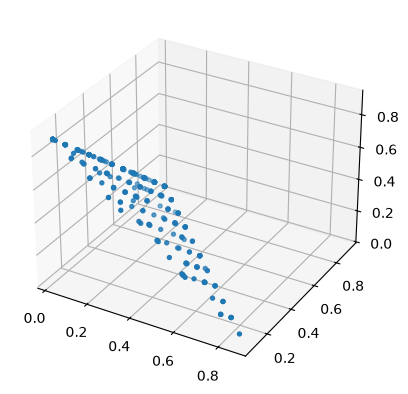

In [18]:
topic_vecs = model.seq_posterior(model.dist_to_encoder().seq_encode(docs_cnt))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(topic_vecs[:, 0], topic_vecs[:, 1], topic_vecs[:, 2], s=8);

## More mixture variants

`MixtureDistribution` is the workhorse, but the library ships several specialized mixtures. All share the same construct → `optimize` → `.components`/`.w` pattern.


In [19]:
# HeterogeneousMixture — components need not be the same family; weights can be fixed
het = HeterogeneousMixtureDistribution([GaussianDistribution(-3, 1), GaussianDistribution(3, 1)], [0.5, 0.5])
hd = het.sampler(seed=1).sample(800)
hm = optimize(hd, HeterogeneousMixtureEstimator([GaussianEstimator(), GaussianEstimator()]),
              max_its=40, rng=np.random.RandomState(1), out=io.StringIO())
print('HeterogeneousMixture means:', sorted(round(c.mu, 2) for c in hm.components))

# DiracLengthMixture — a point mass at v mixed with a count distribution (zero-inflation)
zi = DiracLengthMixtureDistribution(CategoricalDistribution({2: 0.3, 3: 0.3, 4: 0.4}), p=0.6, v=0)
zd = zi.sampler(seed=1).sample(500)
zm = optimize(zd, DiracLengthMixtureEstimator(CategoricalEstimator(), v=0),
              max_its=20, rng=np.random.RandomState(1), out=io.StringIO())
print('DiracLengthMixture inflation p=%.2f (truth 0.6); fraction at 0 = %.2f'
      % (zm.p, np.mean(np.array(zd) == 0)))

# SemiSupervisedMixture — same as Mixture but datapoints may carry a label distribution
ssm = SemiSupervisedMixtureDistribution([GaussianDistribution(-3, 1), GaussianDistribution(3, 1)], [0.5, 0.5])
print('SemiSupervisedMixture: accepts (x, label_weights) so partially-labelled data guides EM')

HeterogeneousMixture means: [-3.06, 2.99]
DiracLengthMixture inflation p=0.81 (truth 0.6); fraction at 0 = 0.39
SemiSupervisedMixture: accepts (x, label_weights) so partially-labelled data guides EM


## Sequence models and decoding

A fitted `HiddenMarkovModel` does more than score - it decodes the hidden state path. `viterbi(seq)` returns the single most-likely state sequence; `seq_posterior(enc)` returns the per-timestep state posteriors (the smoothed forward-backward marginals).


fitted state means: [-3.07, 2.97]
viterbi path (first 25): [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


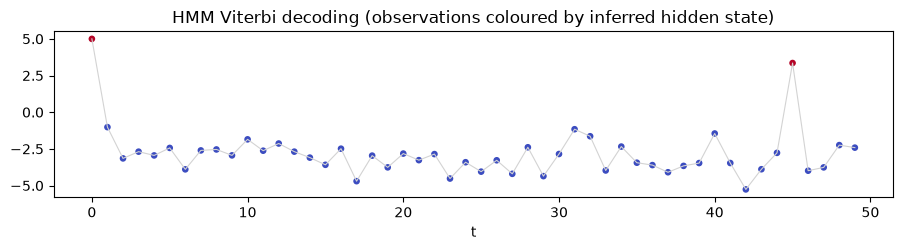

In [20]:
# fit a 2-state Gaussian HMM, then decode the hidden state path with Viterbi
hmm_t = HiddenMarkovModelDistribution([GaussianDistribution(-3, 1), GaussianDistribution(3, 1)],
                                      [0.5, 0.5], [[0.92, 0.08], [0.08, 0.92]], len_dist=PoissonDistribution(40.0))
hseqs = [list(hmm_t.sampler(seed=s).sample()) for s in range(40)]
hmm = optimize(hseqs, HiddenMarkovEstimator([GaussianEstimator(), GaussianEstimator()],
               len_estimator=PoissonEstimator()), max_its=25, rng=np.random.RandomState(1), out=io.StringIO())

seq = hseqs[0]
path = hmm.viterbi(seq)                          # most-likely hidden state at each step
print('fitted state means:', sorted(round(c.mu, 2) for c in hmm.topics))
print('viterbi path (first 25):', path[:25])

fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot(seq, color='lightgray', lw=0.8)
ax.scatter(range(len(seq)), seq, c=path, cmap='coolwarm', s=14)
ax.set_title('HMM Viterbi decoding (observations coloured by inferred hidden state)'); ax.set_xlabel('t')
plt.tight_layout(); plt.show()

In [21]:
# Tree-structured and segmental HMMs — same emission-family flexibility, richer latent structure
tree_t = TreeHiddenMarkovModelDistribution([GaussianDistribution(0, 1), GaussianDistribution(8, 1)],
            [0.6, 0.4], [[0.7, 0.3], [0.3, 0.7]], len_dist=IntegerCategoricalDistribution(0, [0, 0, 0.5, 0.5]))
tree = optimize(tree_t.sampler(seed=1).sample(120),
                TreeHiddenMarkovEstimator([GaussianEstimator(), GaussianEstimator()], use_numba=False),
                max_its=20, rng=np.random.RandomState(1), out=io.StringIO())
print('TreeHiddenMarkovModel fitted (latent state on a tree, not a chain)')

seg_t = SegmentalHiddenMarkovModelDistribution([GaussianDistribution(-2, 1), GaussianDistribution(2, 1)],
          [0.5, 0.5], [[0.6, 0.4], [0.4, 0.6]], len_dist=IntegerCategoricalDistribution(0, [0, 0, 1.0]))
seg_data = seg_t.sampler(3).sample(80)
seg_est = SegmentalHiddenMarkovModelEstimator([GaussianEstimator(), GaussianEstimator()],
                                              len_estimator=IntegerCategoricalEstimator())
seg = seq_estimate(seq_encode(seg_data, estimator=seg_est), seg_est, seg_t)
print('SegmentalHiddenMarkovModel fitted (each state emits a whole variable-length segment)')

TreeHiddenMarkovModel fitted (latent state on a tree, not a chain)
SegmentalHiddenMarkovModel fitted (each state emits a whole variable-length segment)


/var/folders/4k/23vz9g1x43nfgwlsdx7036hc0000gn/T/ipykernel_73455/1467467941.py:4: UserWarning: optimize() stopped at the max_its cap (20) before the objective settled (last objective gain 4.57e-06, delta=1e-09): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  tree = optimize(tree_t.sampler(seed=1).sample(120),


## Grammar and topic models

LDA (above) factorizes documents into topics. `HeterogeneousPCFG` is a probabilistic context-free grammar whose terminals are arbitrary emission distributions; `IntegerPLSI` is the PLSI topic model (covered in depth in topic_modeling_plsi).


In [22]:
# HeterogeneousPCFG: binary rules over symbols, terminals are emission distributions
pcfg = HeterogeneousPCFGDistribution(
    binary_rules={'S': [('A', 'B', 0.5), ('B', 'A', 0.5)]},
    terminal_rules={'A': [(GaussianDistribution(-1.0, 0.8), 1.0)],
                    'B': [(StudentTDistribution(5.0, loc=1.0, scale=1.2), 1.0)]},
    start='S')
trees = pcfg.sampler(11).sample(40)
print('PCFG: sampled %d parse trees; log-density of one = %.2f' % (len(trees), pcfg.log_density(trees[0])))

PCFG: sampled 40 parse trees; log-density of one = -4.56


## Dependency-tree models

`ChowLiuTree` learns the maximum-likelihood tree of pairwise dependencies between features (the Chow-Liu algorithm); `ICLTree` is its conditional-independence cousin over discrete features.


In [23]:
# binary chain a -> b -> c; Chow-Liu should recover the chain topology
rng2 = np.random.RandomState(0); chain = []
for _ in range(800):
    a = rng2.rand() < 0.5
    b = a if rng2.rand() < 0.85 else (not a)
    c = b if rng2.rand() < 0.85 else (not b)
    chain.append((int(a), int(b), int(c)))
clt = optimize(chain, ChowLiuTreeEstimator([BernoulliEstimator()] * 3),
               max_its=1, rng=np.random.RandomState(1), out=io.StringIO())
print('ChowLiuTree recovered parents:', list(clt.parents), '(None = root; a<-b<-c chain)')

icl_data = [(int(x), int(x if rng2.rand() < 0.7 else rng2.randint(3))) for x in rng2.randint(0, 3, 800)]
icl = optimize(icl_data, IntegerChowLiuTreeEstimator(num_features=2, num_states=3, pseudo_count=0.1),
               max_its=1, rng=np.random.RandomState(1), out=io.StringIO())
print('ICLTree fitted over 2 discrete features')

ChowLiuTree recovered parents: [None, 0, 1] (None = root; a<-b<-c chain)
ICLTree fitted over 2 discrete features


/var/folders/4k/23vz9g1x43nfgwlsdx7036hc0000gn/T/ipykernel_73455/1113209328.py:8: UserWarning: optimize() stopped at the max_its cap (1) before the objective settled (last objective gain 36.5, delta=1e-09): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  clt = optimize(chain, ChowLiuTreeEstimator([BernoulliEstimator()] * 3),
/var/folders/4k/23vz9g1x43nfgwlsdx7036hc0000gn/T/ipykernel_73455/1113209328.py:13: UserWarning: optimize() stopped at the max_its cap (1) before the objective settled (last objective gain 24.3, delta=1e-09): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  icl = optimize(icl_data, IntegerChowLiuTreeEstimator(num_features=2, num_states=3, pseudo_count=0.1),


## Latent-feature and association models

`IndianBuffetProcess` is a nonparametric latent-feature model (each item owns a sparse subset of an unbounded feature pool); `SparseMarkovAssociation` models source→target token associations (e.g. translation alignment); `IntegerHiddenAssociation` is its gated multi-source variant.


In [24]:
# Indian Buffet Process — binary feature ownership, dense format
ibp_t = IndianBuffetProcessDistribution(4, alpha=2.0, data_format='dense')
ibp = optimize(ibp_t.sampler(seed=1).sample(500),
               IndianBuffetProcessEstimator(4, alpha=2.0, data_format='dense'),
               max_its=30, rng=np.random.RandomState(1), out=io.StringIO())
print('IndianBuffetProcess fitted (sparse latent-feature ownership)')

# SparseMarkovAssociation — (sources, targets) token pairs with weights
rng3 = np.random.RandomState(0)
pairs = [([(int(rng3.randint(5)), 1.0) for _ in range(3)], [(int(rng3.randint(5)), 1.0) for _ in range(3)])
         for _ in range(120)]
sma = optimize(pairs, SparseMarkovAssociationEstimator(num_vals=5, alpha=0.3),
               max_its=10, rng=np.random.RandomState(1), out=io.StringIO())
print('SparseMarkovAssociation fitted (source->target alignment weights)')

IndianBuffetProcess fitted (sparse latent-feature ownership)


/var/folders/4k/23vz9g1x43nfgwlsdx7036hc0000gn/T/ipykernel_73455/1077051537.py:12: UserWarning: optimize() stopped at the max_its cap (10) before the objective settled (last objective gain 0.0607, delta=1e-09): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  sma = optimize(pairs, SparseMarkovAssociationEstimator(num_vals=5, alpha=0.3),


SparseMarkovAssociation fitted (source->target alignment weights)


## Random-graph models

`ErdosRenyiGraph` (every edge iid Bernoulli) and `StochasticBlockGraph` (edge probability depends on node block membership) are distributions over graphs - fit via the accumulator protocol on graph observations.


In [25]:
# Erdos-Renyi: recover the global edge probability
er_t = ErdosRenyiGraphDistribution(0.3, num_nodes=12)
graphs = [er_t.sampler(seed=s).sample() for s in range(60)]
acc = ErdosRenyiGraphEstimator().accumulator_factory().make()
for g in graphs: acc.update(g, 1.0, None)
er = ErdosRenyiGraphEstimator().estimate(len(graphs), acc.value())
print('ErdosRenyiGraph edge prob: %.3f (truth 0.3)' % er.p)

# Stochastic block model: two communities, dense within / sparse between
sbm_t = StochasticBlockGraphDistribution([[0.7, 0.1], [0.1, 0.7]], [0, 0, 0, 1, 1, 1])
sbm_graphs = [sbm_t.sampler(seed=s).sample() for s in range(50)]
sbm_est = StochasticBlockGraphEstimator(num_blocks=2, block_assignments=[0, 0, 0, 1, 1, 1])
sacc = sbm_est.accumulator_factory().make()
for g in sbm_graphs: sacc.update(g, 1.0, None)
sbm = sbm_est.estimate(len(sbm_graphs), sacc.value())
print('StochasticBlockGraph fitted (block-structured connectivity)')

ErdosRenyiGraph edge prob: 0.303 (truth 0.3)
StochasticBlockGraph fitted (block-structured connectivity)


## Nonparametric mixtures - let the data choose K

A `DirichletProcessMixture` fits a truncated stick-breaking mixture and starves the components the data doesn't need (give the leaves conjugate priors - see bayesian_distributions). `HierarchicalDirichletProcessMixture` shares a global pool of clusters across groups.


DPM active components (w>3%): 3  (truth 3)
HDPM fitted (a global cluster menu shared across the 5 groups)


/var/folders/4k/23vz9g1x43nfgwlsdx7036hc0000gn/T/ipykernel_73455/1796548913.py:2: UserWarning: optimize() stopped at the max_its cap (120) before the objective settled (last objective gain 6.33e-09, delta=1e-09): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  dpm = optimize(dpm_data,
/var/folders/4k/23vz9g1x43nfgwlsdx7036hc0000gn/T/ipykernel_73455/1796548913.py:12: UserWarning: optimize() stopped at the max_its cap (40) before the objective settled (last objective gain 0.000332, delta=1e-09): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  hdp = optimize(hdp_groups,


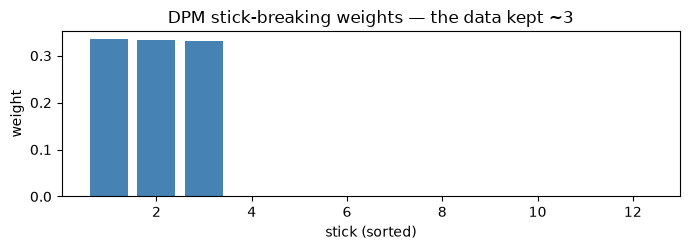

In [26]:
dpm_data = list(np.r_[rng.normal(-6, 1, 300), rng.normal(0, 1, 300), rng.normal(6, 1, 300)])  # truth K=3
dpm = optimize(dpm_data,
               DirichletProcessMixtureEstimator(
                   [GaussianEstimator(prior=NormalGammaDistribution(0.0, 1e-3, 1.0, 1.0)) for _ in range(12)],
                   prior=GammaDistribution(2, 1)),
               max_its=120, rng=np.random.RandomState(1), out=io.StringIO())
w = np.sort(np.asarray(dpm.w))[::-1]
print('DPM active components (w>3%%): %d  (truth 3)' % int((np.asarray(dpm.w) > 0.03).sum()))

# HDP mixture: clusters shared across groups
hdp_groups = [list(rng.normal(loc, 1, 60)) for loc in [-6, -6, 0, 6, 6]]
hdp = optimize(hdp_groups,
               HierarchicalDirichletProcessMixtureEstimator(
                   [GaussianEstimator(prior=NormalGammaDistribution(0.0, 1e-3, 1.0, 1.0)) for _ in range(10)],
                   gamma=1.0, alpha=1.0),
               max_its=40, rng=np.random.RandomState(1), out=io.StringIO())
print('HDPM fitted (a global cluster menu shared across the 5 groups)')

fig, ax = plt.subplots(figsize=(7, 2.6))
ax.bar(range(1, 13), w, color='steelblue')
ax.set_xlabel('stick (sorted)'); ax.set_ylabel('weight'); ax.set_title('DPM stick-breaking weights — the data kept ~3')
plt.tight_layout(); plt.show()